# Welcome to the VICTOR-OPERA lava flow extraction workflow

### In this notebook, you will specify a few parameters, including an area and time range, to access vegetative disturbance (DIST) data.

To begin, the user must load in relevant libraries, as well as sign into their EarthData account to authenticate their access.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from netrc import netrc
from subprocess import Popen
from platform import system
from getpass import getpass

from pystac_client import Client  

import json

import matplotlib.pyplot as plt
from matplotlib import cm
from datetime import datetime

from shapely.geometry import box
from shapely.geometry import shape
from shapely.ops import transform
from shapely import wkt
from pyproj import Transformer

import numpy as np
import pandas as pd
import geopandas as gpd

import rioxarray as rxr
import xarray as xr
import rasterio as rio

from osgeo import gdal

import pyproj
from pyproj import Proj

import geoviews as gv
import hvplot.xarray
import holoviews as hv
hv.extension('bokeh')
gv.extension('bokeh', 'matplotlib')

import sys
sys.path.append('./')
from src.dist_utils import intersection_percent, colorize, getbasemaps, transform_data_for_folium

import leafmap

import warnings
warnings.filterwarnings('ignore')

In [2]:
inDir = os.getcwd()
os.chdir(inDir)

# Generates authentication token
# Asks for your Earthdata username and password for first time, if netrc does not exists in your home directory.

urs = 'urs.earthdata.nasa.gov'    # Earthdata URL endpoint for authentication
prompts = ['Enter NASA Earthdata Login Username: ',
           'Enter NASA Earthdata Login Password: ']

# Determine the OS (Windows machines usually use an '_netrc' file)
netrc_name = "_netrc" if system()=="Windows" else ".netrc"

# Determine if netrc file exists, and if so, if it includes NASA Earthdata Login Credentials
try:
    netrcDir = os.path.expanduser(f"~/{netrc_name}")
    netrc(netrcDir).authenticators(urs)[0]

# Below, create a netrc file and prompt user for NASA Earthdata Login Username and Password
except FileNotFoundError:
    homeDir = os.path.expanduser("~")
    Popen('touch {0}{2} | echo machine {1} >> {0}{2}'.format(homeDir + os.sep, urs, netrc_name), shell=True)
    Popen('echo login {} >> {}{}'.format(getpass(prompt=prompts[0]), homeDir + os.sep, netrc_name), shell=True)
    Popen('echo \'password {} \'>> {}{}'.format(getpass(prompt=prompts[1]), homeDir + os.sep, netrc_name), shell=True)
    # Set restrictive permissions
    Popen('chmod 0600 {0}{1}'.format(homeDir + os.sep, netrc_name), shell=True)

    # Determine OS and edit netrc file if it exists but is not set up for NASA Earthdata Login
except TypeError:
    homeDir = os.path.expanduser("~")
    Popen('echo machine {1} >> {0}{2}'.format(homeDir + os.sep, urs, netrc_name), shell=True)
    Popen('echo login {} >> {}{}'.format(getpass(prompt=prompts[0]), homeDir + os.sep, netrc_name), shell=True)
    Popen('echo \'password {} \'>> {}{}'.format(getpass(prompt=prompts[1]), homeDir + os.sep, netrc_name), shell=True)# GDAL configurations used to successfully access PODAAC Cloud Assets via vsicurl 

gdal.SetConfigOption('GDAL_HTTP_COOKIEFILE','~/cookies.txt')
gdal.SetConfigOption('GDAL_HTTP_COOKIEJAR', '~/cookies.txt')
gdal.SetConfigOption('GDAL_DISABLE_READDIR_ON_OPEN','EMPTY_DIR')
gdal.SetConfigOption('CPL_VSIL_CURL_ALLOWED_EXTENSIONS','TIF, TIFF')
gdal.SetConfigOption('CPL_VSIL_CURL_USE_HEAD', 'YES')


### To begin, run the following cell and mark out an area with the rectangle or polygon tools on the map below. 

In [3]:
import leafmap
m = leafmap.Map(center=[65,-19], zoom=6)
m

Map(center=[65, -19], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_te…

In [8]:
bounds = m.user_roi_bounds()

In [9]:
from shapely.geometry import box
aoi = box(bounds[0],bounds[1],bounds[2],bounds[3])

### Next, specify the start and stop dates of the eruption you want to track (in year, month, day format as shown by the defaults below)

In [10]:
start_date = datetime(2024, 3, 1)                                       # in 2022-01-01 00:00:00 format
stop_date = datetime(2024, 6, 21)  

### Finally, specify the name you would like to use to identify this project, and the % cloud cover and coverage of your area of interest that serve as a threshold for parsing data.

In [11]:
overlap_threshold = 40                                                  # in percent
cloud_cover_threshold = 100                                             # in percent

project_name = "LavaFlowIceland"

In [12]:
# USER-DEFINED PARAMETERS
save_fn = f"{project_name}_{datetime.strftime(start_date.date(), '%Y%m%d')}_{datetime.strftime(stop_date.date(), '%Y%m%d')}_v2"

print(f"Search between {start_date} and {stop_date}")
print(f"With AOI: {aoi.__geo_interface__}")

Search between 2021-08-01 00:00:00 and 2021-08-20 00:00:00
With AOI: {'type': 'Polygon', 'coordinates': (((-22.2869, 63.8367), (-22.2869, 63.931), (-22.519, 63.931), (-22.519, 63.8367), (-22.2869, 63.8367)),)}


In [13]:
# Search data through CMR-STAC API
stac = 'https://cmr.earthdata.nasa.gov/cloudstac'    # CMR-STAC API Endpoint
api = Client.open(f'{stac}/LPCLOUD/')
collections = ['OPERA_L3_DIST-ALERT-HLS_V1_1']

search_params = {"collections": collections,
                 "intersects": aoi.__geo_interface__,
                 "datetime": [start_date, stop_date],
                 "max_items": 1000}
search_data = api.search(**search_params)

In [14]:
# Filter datasets based on spatial overlap 
intersects_geometry = aoi.__geo_interface__

#Check percent overlap values
print("Percent overlap before filtering: ")
print([f"{intersection_percent(i, intersects_geometry):.2f}" for i in search_data.items()])

# Check percent cloud cover values
print("\nPercent cloud cover before filtering: ")
print([f"{i.properties['eo:cloud_cover']}" for i in search_data.items()])

# Apply spatial overlap and cloud cover filter
dist_filtered = (
    i for i in search_data.items() if ((intersection_percent(i, intersects_geometry) > overlap_threshold) & (i.properties['eo:cloud_cover'] <= cloud_cover_threshold))
)


Percent overlap before filtering: 
[]

Percent cloud cover before filtering: 
[]


In [11]:
# Inspect the items inside the filtered query
dist_data = list(dist_filtered)
# Inspect one data
dist_data[0].to_dict()

{'type': 'Feature',
 'stac_version': '1.1.0',
 'stac_extensions': ['https://stac-extensions.github.io/eo/v1.1.0/schema.json'],
 'id': 'OPERA_L3_DIST-ALERT-HLS_T27VVL_20240302T131301Z_20240304T164845Z_S2A_30_v1',
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-21.415571, 63.0411322],
    [-20.8070327, 63.0426875],
    [-20.8002655, 64.0270166],
    [-23.0464985, 64.0127397],
    [-22.9996312, 63.3556837],
    [-21.415571, 63.0411322]]]},
 'bbox': [-23.0464985, 63.0411322, -20.8002655, 64.0270166],
 'properties': {'datetime': '2024-03-02T13:14:08.525000Z',
  'eo:cloud_cover': 2,
  'start_datetime': '2024-03-02T13:14:08.525Z',
  'end_datetime': '2024-03-02T13:14:08.525Z'},
 'links': [{'rel': 'self',
   'href': 'https://cmr.earthdata.nasa.gov/cloudstac/LPCLOUD/collections/OPERA_L3_DIST-ALERT-HLS_V1_1/items/OPERA_L3_DIST-ALERT-HLS_T27VVL_20240302T131301Z_20240304T164845Z_S2A_30_v1',
   'type': 'application/geo+json'},
  {'rel': 'parent',
   'href': 'https://cmr.earthdata.nasa.gov/clou

In [12]:
## Print search information
# Tota granules
print(f"Total granules after search filter: {len(dist_data)}")

#Check percent overlap values
print("Percent-overlap: ")
print([f"{intersection_percent(i, intersects_geometry):.2f}" for i in dist_data])

# Check percent cloud cover values
print("\nPercent cloud cover: ")
print([f"{i.properties['eo:cloud_cover']}" for i in dist_data])

Total granules after search filter: 61
Percent-overlap: 
['100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00']

Percent cloud cover: 
['2', '52', '100', '100', '98', '50', '100', '98', '98', '96', '90', '100', '6', '46', '6', '100', '51', '28', '81', '21', '100', '7', '100', '0', '94', '33', '1', '100', '24', '3', '75', '19', '68', '66', '50', '30', '24', '17', '100', '80', '75', '37', '100', '83', '100', '100', '55', '55', '51', '35', '11

In [13]:
# Visualize the DIST tile boundary and the user-defined bbox
geom_df = []
for d,_ in enumerate(dist_data):
    geom_df.append(shape(dist_data[d].geometry))

geom_granules = gpd.GeoDataFrame({'geometry':geom_df})
granules_poly = gv.Polygons(geom_granules, label='DIST tile boundary').opts(line_color='blue', color=None, show_legend=True)

# Use geoviews to combine a basemap with the shapely polygon of our Region of Interest (ROI)
base = gv.tile_sources.EsriImagery.opts(width=1000, height=1000)

# Get the user-specified aoi
geom_aoi = shape(intersects_geometry)
aoi_poly = gv.Polygons(geom_aoi, label='User-specified bbox').opts(line_color='yellow', color=None, show_legend=True)

# Plot using geoviews wrapper
granules_poly*base*aoi_poly

:Overlay
   .Polygons.DIST_tile_boundary               :Polygons   [Longitude,Latitude]
   .WMTS.I                                    :WMTS   [Longitude,Latitude]
   .Polygons.User_hyphen_minus_specified_bbox :Polygons   [Longitude,Latitude]

In [14]:
# Create table of search results
dist_data_df = []
for item in dist_data:
    item.to_dict()
    fn = item.id.split('_')
    ID = fn[3]
    fileID = item.id
    sensor = fn[6]
    # dat = item.datetime.strftime('%Y-%m-%d')
    dat = item.datetime
    spatial_overlap = intersection_percent(item, intersects_geometry)
    cloud_cover = item.properties['eo:cloud_cover']
    geom = item.geometry
    bbox = item.bbox

    # Take all the band href information 
    band_links = [item.assets[links].href for links in item.assets.keys()]
    dist_data_df.append([ID,fileID,sensor,dat,geom,bbox,spatial_overlap,cloud_cover,band_links])

dist_data_df = pd.DataFrame(dist_data_df, columns = ['TileID', 'FileID', 'Sensor', 'Date', 'Coords', 'bbox', 'SpatialOverlap', 'CloudCover', 'BandLinks'])
dist_data_df = dist_data_df.drop_duplicates(subset='Date', ignore_index=True)
dist_data_df

,TileID,FileID,Sensor,Date,Coords,bbox,SpatialOverlap,CloudCover,BandLinks
0,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240302T131301...,S2A,2024-03-02 13:14:08.525000+00:00,"{'type': 'Polygon', 'coordinates': [[[-21.4155...","[-23.0464985, 63.0411322, -20.8002655, 64.0270...",100.0,2,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
1,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240304T130259...,S2B,2024-03-04 13:04:06.333000+00:00,"{'type': 'Polygon', 'coordinates': [[[-20.8069...","[-23.0464985, 63.0615354, -20.8002655, 64.0270...",100.0,52,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
2,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240306T124625...,L9,2024-03-06 12:46:25.506000+00:00,"{'type': 'Polygon', 'coordinates': [[[-20.8059...","[-23.0464985, 63.2072007, -20.8002655, 64.0270...",100.0,100,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
3,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240309T130301...,S2A,2024-03-09 13:04:11.097000+00:00,"{'type': 'Polygon', 'coordinates': [[[-20.8070...","[-23.0464985, 63.0416105, -20.8002655, 64.0270...",100.0,100,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
4,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240312T131301...,S2A,2024-03-12 13:14:09.166000+00:00,"{'type': 'Polygon', 'coordinates': [[[-22.2837...","[-23.0464985, 63.0359221, -20.8002655, 64.0270...",100.0,98,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
5,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240313T125234...,L9,2024-03-13 12:52:34.763000+00:00,"{'type': 'Polygon', 'coordinates': [[[-21.7509...","[-23.0464985, 63.098182, -20.9064765, 64.0271238]",100.0,50,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
6,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240314T124604...,L8,2024-03-14 12:46:04.281000+00:00,"{'type': 'Polygon', 'coordinates': [[[-20.8059...","[-23.0464985, 63.2098931, -20.8002655, 64.0270...",100.0,100,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
7,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240317T131259...,S2B,2024-03-17 13:14:06.924000+00:00,"{'type': 'Polygon', 'coordinates': [[[-21.2151...","[-23.0464985, 63.0415786, -20.8002655, 64.0270...",100.0,98,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
8,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240319T130301...,S2A,2024-03-19 13:04:11.281000+00:00,"{'type': 'Polygon', 'coordinates': [[[-20.8069...","[-23.0464985, 63.05265, -20.8002655, 64.0270166]",100.0,98,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
9,T27VVL,OPERA_L3_DIST-ALERT-HLS_T27VVL_20240322T124622...,L9,2024-03-22 12:46:22.081000+00:00,"{'type': 'Polygon', 'coordinates': [[[-20.8059...","[-23.0464985, 63.2039697, -20.8002655, 64.0270...",100.0,96,[https://data.lpdaac.earthdatacloud.nasa.gov/l...


In [15]:
def stack_bands(bandpath:str, bandlist:list): 
    '''
    Returns geocube with three bands stacked into one multi-dimensional array.
            Parameters:
                    bandpath (str): Path to bands that should be stacked
                    bandlist (list): Three bands that should be stacked
            Returns:
                    bandStack (xarray Dataset): Geocube with stacked bands
                    crs (int): Coordinate Reference System corresponding to bands

   '''
    bandStack = []; bandS = []; bandStack_ = [];
    for i,band in enumerate(bandlist):
        if i==0:
            print(f"{bandpath%band}")
            bandStack_ = rxr.open_rasterio(bandpath%band)
            crs = bandStack_.rio.crs.to_epsg()
            bandStack = bandStack_.squeeze(drop=True)
            bandStack = bandStack.to_dataset(name='z')
            bandStack.coords['band'] = i+1
            bandStack = bandStack.rename({'x':'longitude', 'y':'latitude', 'band':'band'})
            bandStack = bandStack.expand_dims(dim='band')  
        else:
            bandS = rxr.open_rasterio(bandpath%band)
            bandS = bandS.squeeze(drop=True)
            bandS = bandS.to_dataset(name='z')
            bandS.coords['band'] = i+1
            bandS = bandS.rename({'x':'longitude', 'y':'latitude', 'band':'band'})
            bandS = bandS.expand_dims(dim='band')
            bandStack = xr.concat([bandStack, bandS], dim='band')
    return bandStack, crs

In [16]:
data_dir = f"https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/{fileID}/{fileID}_"
bandlist = ['VEG-DIST-STATUS', 'VEG-ANOM-MAX', 'VEG-DIST-DATE', 'VEG-DIST-DUR']
bandpath = f"{data_dir}%s.tif"
fileID

'OPERA_L3_DIST-ALERT-HLS_T27VVL_20240627T130301Z_20240629T051210Z_S2A_30_v1'

In [17]:
# Creates geocube of stacked bands
da, crs = stack_bands(bandpath, bandlist)

https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/OPERA_L3_DIST-ALERT-HLS_T27VVL_20240627T130301Z_20240629T051210Z_S2A_30_v1/OPERA_L3_DIST-ALERT-HLS_T27VVL_20240627T130301Z_20240629T051210Z_S2A_30_v1_VEG-DIST-STATUS.tif


In [18]:
# Creates basemap
base = gv.tile_sources.EsriTerrain.opts(width=1000, height=1000, padding=0.1)

In [19]:
base = gv.tile_sources.EsriNatGeo.opts(width=1000, height=1000, padding=0.1)
veg_dist_status = da.z.sel({'band':1})
veg_dist_status.hvplot.image(x='longitude', 
                          y='latitude', 
                          crs=crs, 
                          rasterize=True, 
                          dynamic=True, 
                          aspect='equal', 
                          frame_width=500, 
                          frame_height=500, 
                          cmap='hot_r', 
                          clim=(0,8), alpha=0.8).opts(title=f"VEG_DIST_STATUS", xlabel='Longitude', ylabel='Latitude') * base



:DynamicMap   []
   :Overlay
      .Image.I :Image   [longitude,latitude]   (Vegetation_disturbance_status)
      .WMTS.I  :WMTS   [Longitude,Latitude]

In [20]:
veg_anom_max = da.z.sel({'band':2})
veg_anom_max.hvplot.image(x='longitude', 
                          y='latitude', 
                          crs=crs, 
                          rasterize=True, 
                          dynamic=True, 
                          aspect='equal', 
                          frame_width=500, 
                          frame_height=500, 
                          cmap='hot_r', 
                          clim=(0,100), alpha=0.8).opts(title=f"VEG_ANOM_MAX", xlabel='Longitude', ylabel='Latitude') * base

:DynamicMap   []
   :Overlay
      .Image.I :Image   [longitude,latitude]   (Vegetation_disturbance_status)
      .WMTS.I  :WMTS   [Longitude,Latitude]

In [21]:
def read_dist(tiffile):
    print(f"{tiffile}")
    dat = rxr.open_rasterio(tiffile)
    epsg = dat.rio.crs.to_proj4()
    dat.closed
    
    return dat, epsg

In [22]:
#load dist
time_coords = []; filepaths_vds=[]; filepaths_vam=[]; filepaths_dat=[]; filepaths_dur=[]; bbox = []
for i, fileID, start_date, bounding_polygon in zip(dist_data_df.index, dist_data_df.FileID, dist_data_df.Date, dist_data_df.bbox):
    data_dir = f"https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/{fileID}/{fileID}_"
    filepaths_vds.append(f"{data_dir}{bandlist[0]}.tif")
    filepaths_vam.append(f"{data_dir}{bandlist[1]}.tif")
    filepaths_dat.append(f"{data_dir}{bandlist[2]}.tif")
    filepaths_dur.append(f"{data_dir}{bandlist[3]}.tif")
    time_coords.append(pd.to_datetime(start_date))
    bbox.append(bounding_polygon)

In [23]:
def read_dist_ts(filepaths, time_coords):
    data_arrays = [rxr.open_rasterio(fp) for fp in filepaths]
    combined_data = xr.concat(data_arrays, dim='time')
    combined_data["time"] = time_coords
    epsg = data_arrays[0].rio.crs.to_epsg()
    return combined_data, epsg

In [24]:
%matplotlib inline

In [25]:
vam, epsg = read_dist_ts(filepaths_vam, time_coords)
vam = vam.squeeze("band")

In [26]:
vam.rio.write_crs(f"EPSG:{epsg}", inplace=True)

<xarray.DataArray (time: 58, y: 3660, x: 3660)> Size: 777MB
array([[[255, 255, 255, ...,  14,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ...,  14,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ...,  14,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        ...,
...
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]]], dtype=uint8)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 29kB 4e+05 4e+05 4e+05 ... 5.097e+05 5.097e+05
  * y            (y) float64 29kB 7.1e+06 7.1e+06 7.1e+06 ... 6.99e+06 6.99e+06
  * time         (time) object 464B 2024-03-02T13:14:08.525000+00:00 ... 2024...
    spatial_ref  int64 8B 0
Attributes:
    Input_DIST-ALERT_granule:  /OPERA_L3_DIST-ALERT-HLS_T27VVL_20240228T12401...
    Percent_Updated:           98.26
    Units:                     percent
    Update_Date:               2024-03-02T13:14:08.525583Z
    Valid_max:                 100
    Valid_min:                 0
    AREA_OR_POINT:             Area
    _FillValue:                255
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 Maximum_vegetation_loss_anomaly

In [27]:
xv, yv = np.meshgrid(vam.x, vam.y)
transformer = Transformer.from_crs(f"EPSG:{epsg}", 
                                   "EPSG:4326",
                                   always_xy=True,
                                  ) 

lon, lat = transformer.transform(xv, yv)
vam.coords['lon'] = (('y', 'x'), lon)
vam.coords['lat'] = (('y', 'x'), lat)
vam.attrs['crs']  = '+init=epsg:4326'

In [28]:
raster_crs = vam.rio.crs

tformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)

aoi_projected = transform(tformer.transform, aoi)

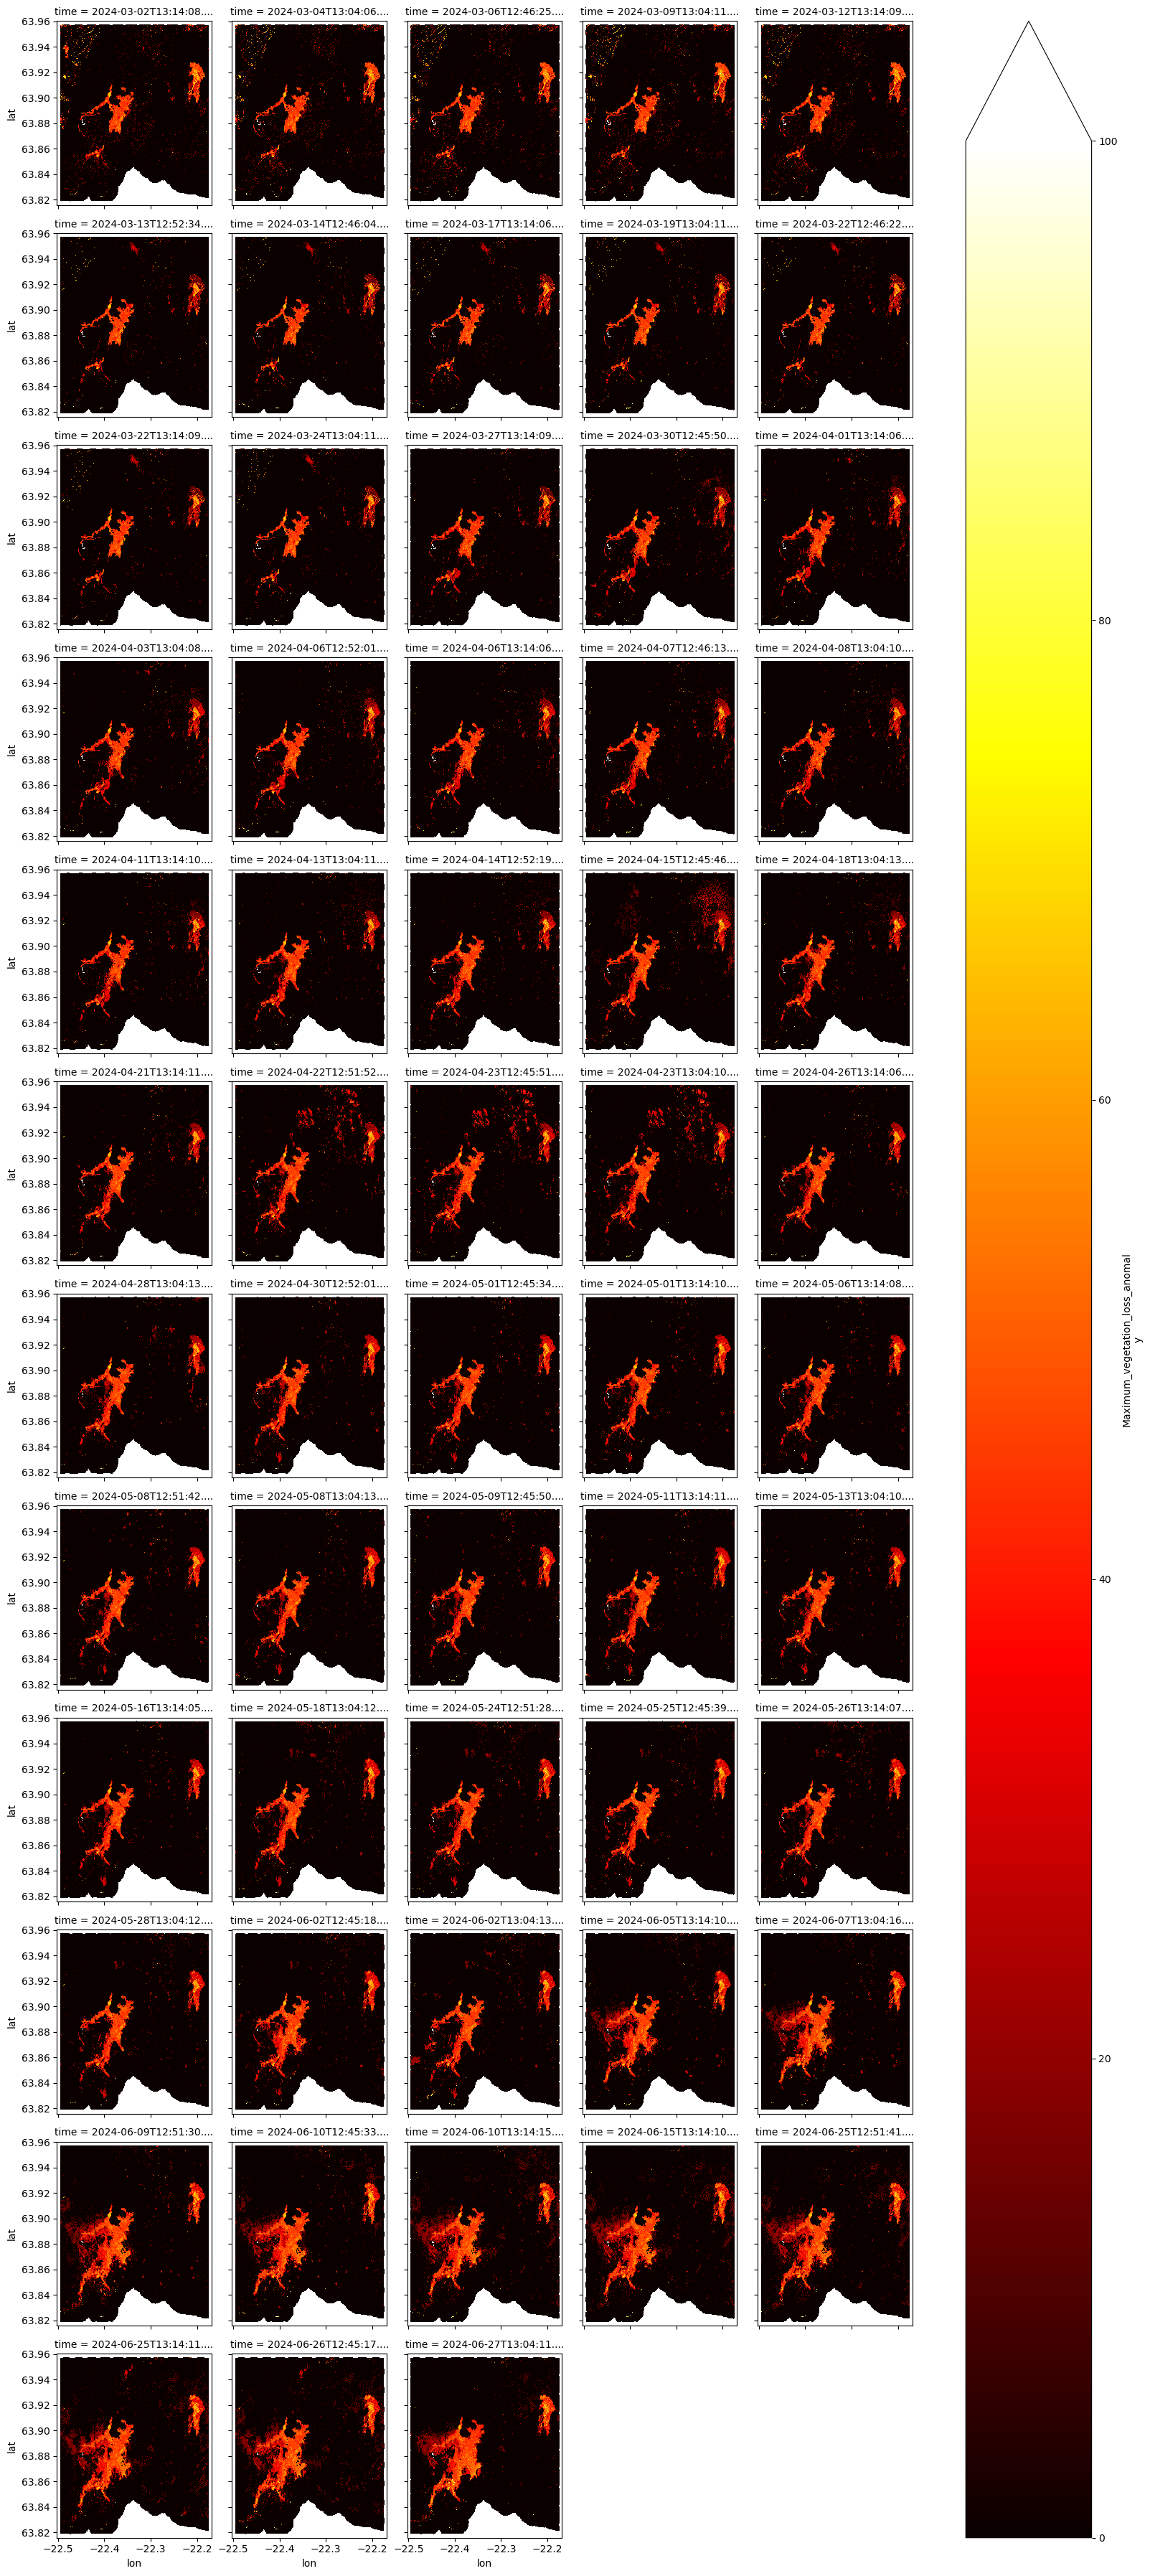

In [29]:
vam.rio.clip([aoi_projected], raster_crs).plot(col='time', y='lat', x='lon', col_wrap=5, vmin=0, vmax=100, cmap='hot')

In [30]:
if vam["time"].dtype == "O":
    vam["time"] = [dt.replace(tzinfo=None) for dt in vam["time"].values]

In [31]:
def binarize_flow(veg_loss_files,filter_level):
    v = veg_loss_files.copy()
    v = v.where(v < 100, 0)
    v = v.where(v.values <= 0, 1)
    v = v.astype(rio.int32)
    v.values = rio.features.sieve(v.values,size=filter_level, connectivity=8)
    v = v.where(v > 0)
    return v

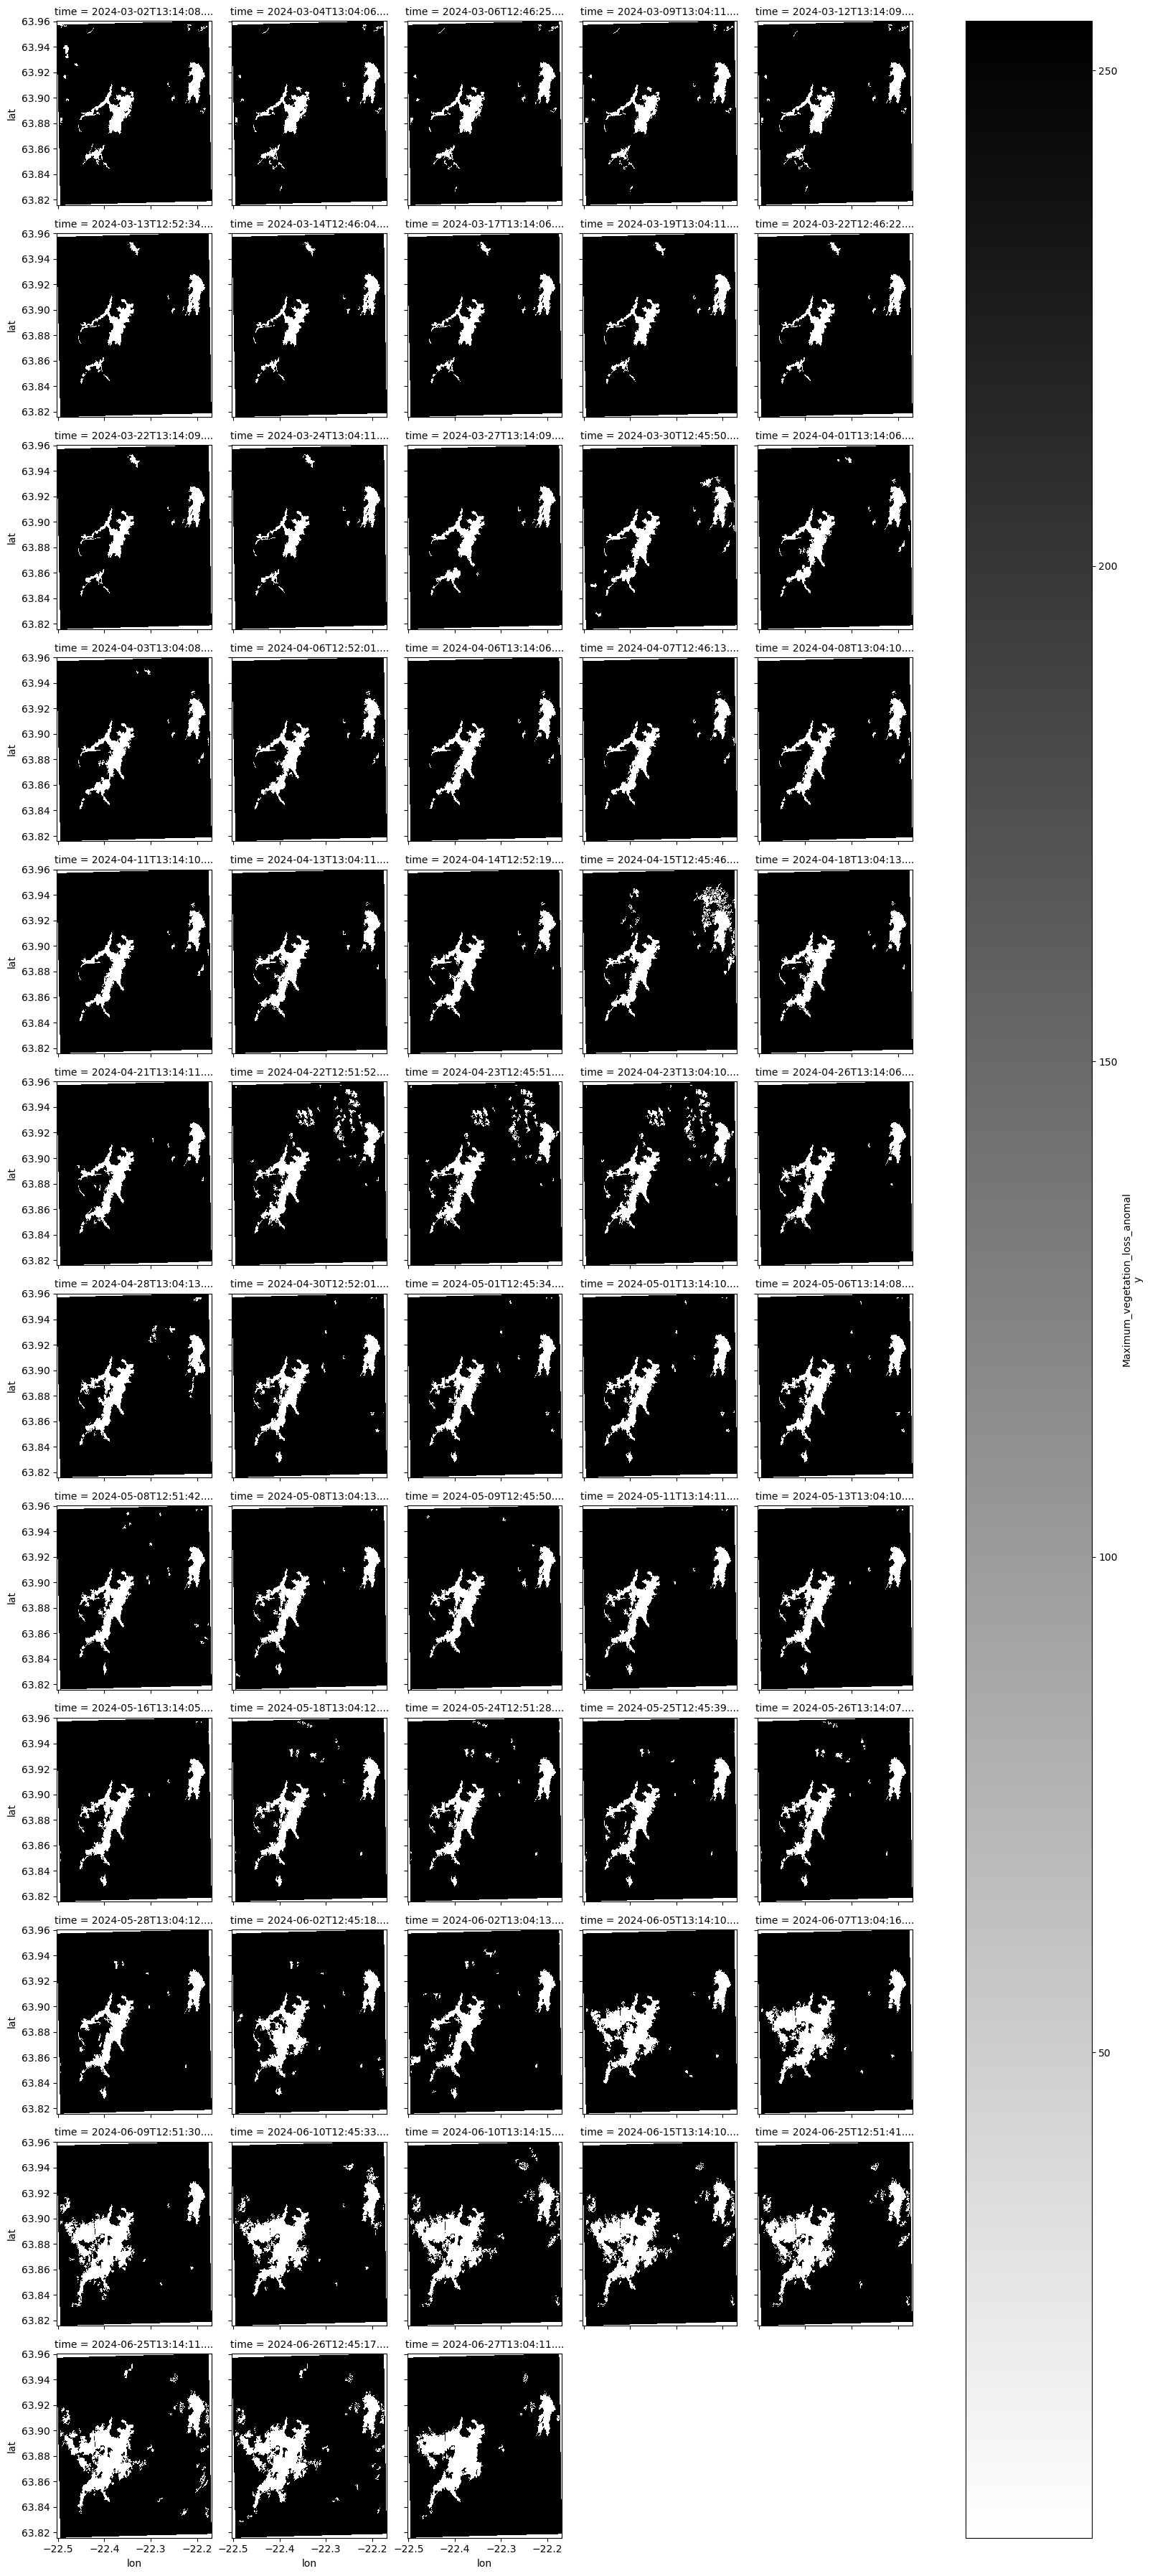

In [36]:
b = binarize_flow(vam,40)
b.rio.clip([aoi_projected], raster_crs).plot(col='time', y='lat', x='lon', col_wrap=5,cmap="binary")

In [33]:
progression = vam[0:58:10,:,:]
binarized = b[0:58:10,:,:]
b[-1].rio.to_raster("iceland_final.tiff")

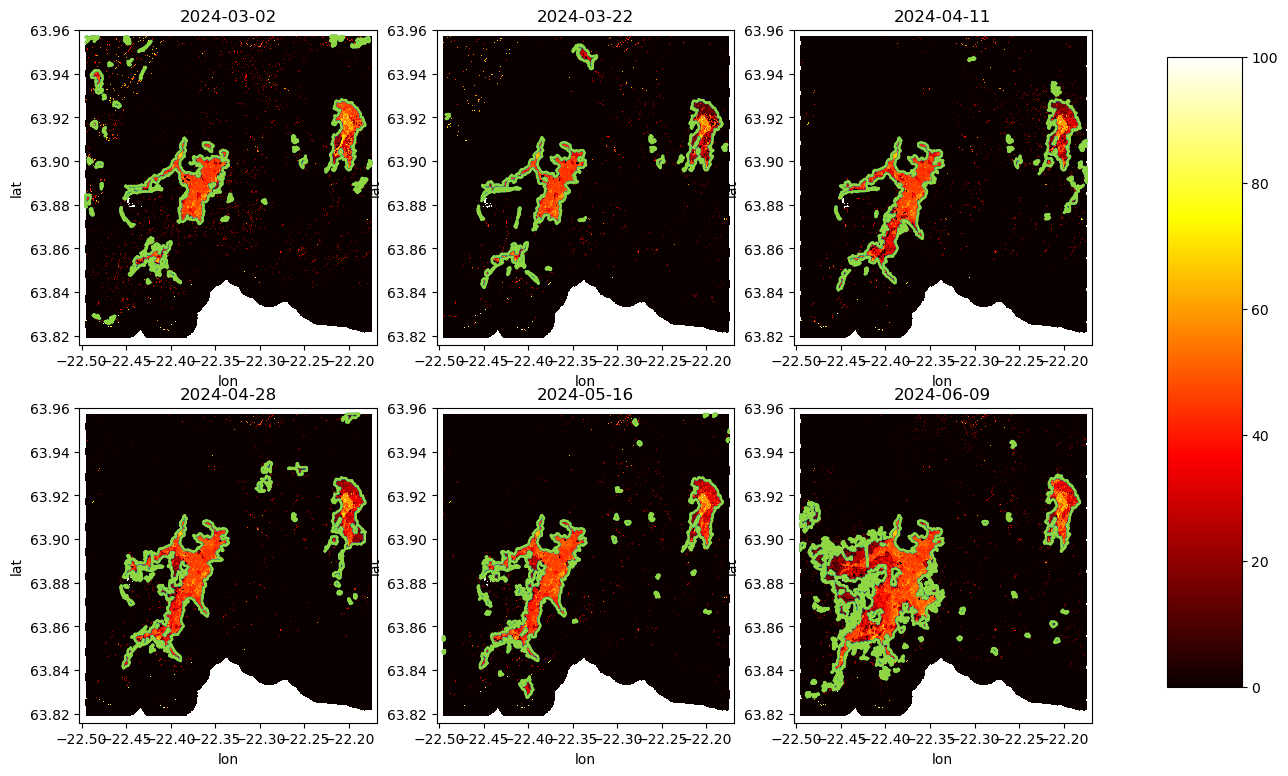

In [37]:
fig, axs = plt.subplots(2,3,figsize = (15,9))
axs = axs.flatten()
t = progression['time'].values
t = np.datetime_as_string(t)
for i in range(progression.sizes['time']):
    bar = progression[i,:,:].rio.clip([aoi_projected], raster_crs).plot(ax=axs[i], y='lat', x='lon', cmap="hot", vmin=0, vmax=100,add_colorbar=False)
    binarized[i,:,:].rio.clip([aoi_projected], raster_crs).plot.contour(ax=axs[i], y='lat', x='lon')
    axs[i].set_title(t[i][0:10])
    # progression[i,:,:].rio.to_raster(f"iceland_{i}.tiff")
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(bar, cax=cbar_ax)
plt.show()

In [35]:
res = b[0].rio.resolution()[0]
footprint = []
for i in range(b.sizes["time"]):
    size = b[i].sum(skipna=True)
    area = size*res
    footprint.append(area.values)

In [79]:
footprint

array(1393560.)

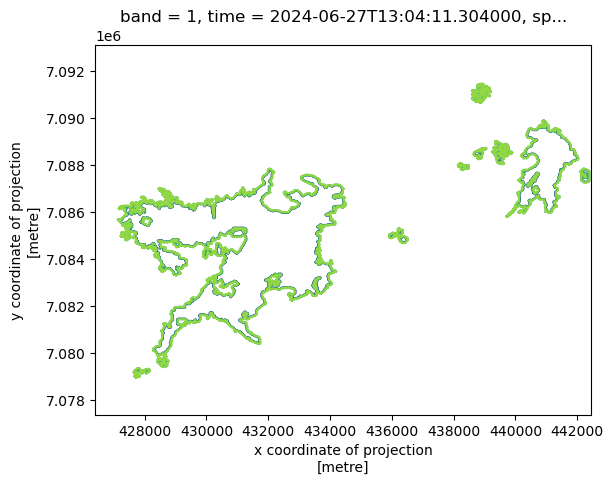

In [41]:
b[-1].rio.clip([aoi_projected], raster_crs).plot.contour()